# OOS CS-LIM + structured TCNN residual hybrid

This notebook does **not** ask a neural network to relearn the complete
11-dimensional dynamics.

For every outer held-out block, it first fits an independent
cyclostationary LIM using only the remaining data:

\[
\widehat{\mathbf{x}}^{\,\mathrm{LIM}}_{t+1}
=
\boldsymbol{\mu}_{y,m}
+
G_m
\left(
\mathbf{x}_t-\boldsymbol{\mu}_{x,m}
\right).
\]

The hybrid forecast then adds a neural correction **only to PP**:

\[
\widehat{PP}_{t+1}
=
\widehat{PP}^{\,\mathrm{LIM}}_{t+1}
+
r_\theta
\left(
\mathbf{x}_{t-11:t},
m_{t+1}
\right).
\]

The residual model is explicitly structured as:

\[
r_\theta
=
r_{\mathrm{PP-memory}}
+
\sum_j r_{\mathrm{PP}\times j}
+
r_{\mathrm{joint}}.
\]

Therefore:

- CS-LIM retains the already skilful multivariate baseline.
- All 11 states are still recursively forecast by CS-LIM.
- The TCNN cannot damage the forecasts of the ten driver states.
- Separate PP–driver pathways learn nonlinear lagged corrections.
- A small joint branch represents interactions involving multiple drivers.
- Training begins from the exact CS-LIM forecast because every final
  correction head is initialized to zero.
- Stage 1 learns one-step CS-LIM residuals.
- Stage 2 optionally fine-tunes the same correction under recursive rollout.
- CS-LIM, hybrid, and persistence are verified using identical OOS folds.


In [1]:
# Blocked-jackknife OOS CS-LIM + TCNN residual hybrid

from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# Settings
# ============================================================

STATE_VECTOR_FILE = (
    "data_input/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_"
    "RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)
STATE_VECTOR_VARIABLE = "state_vector"

TEST_REGIONS = [9, 10, 11]

LOOKBACK = 12
TRAIN_HORIZON = 3
MAX_LEAD = 24

# ------------------------------------------------------------
# Fold-specific CS-LIM
# ------------------------------------------------------------

CSLIM_RIDGE_ALPHA = 1e-3
CSLIM_MIN_MONTHLY_SAMPLES = 12

# ------------------------------------------------------------
# Structured PP residual TCNN
# ------------------------------------------------------------

PAIR_HIDDEN_CHANNELS = 4
PAIR_KERNEL_SIZE = 3
PAIR_DILATIONS = (1, 2, 4)
PAIR_HEAD_LATENT = 4
JOINT_HEAD_LATENT = 4

# The learned scale is bounded between zero and this value.
# All final heads start at zero, so the initial hybrid is exactly
# the fold-specific CS-LIM regardless of this nonzero scale.
MAX_RESIDUAL_SCALE = 0.50
INITIAL_RESIDUAL_SCALE = 0.10

# ------------------------------------------------------------
# Stage 1: one-step residual learning
# ------------------------------------------------------------

STAGE1_EPOCHS = 150
STAGE1_LEARNING_RATE = 1e-3

# ------------------------------------------------------------
# Stage 2: short recursive fine-tuning
# ------------------------------------------------------------

RUN_RECURSIVE_FINE_TUNING = True
STAGE2_EPOCHS = 50
STAGE2_LEARNING_RATE = 3e-4

STAGE2_STATE_WEIGHT = 0.60
STAGE2_DELTA_WEIGHT = 0.25
STAGE2_CORRELATION_WEIGHT = 0.15

if not np.isclose(
    STAGE2_STATE_WEIGHT
    + STAGE2_DELTA_WEIGHT
    + STAGE2_CORRELATION_WEIGHT,
    1.0,
):
    raise ValueError(
        "Stage-2 principal loss weights must sum to one."
    )

# ------------------------------------------------------------
# Shared optimization settings
# ------------------------------------------------------------

BATCH_SIZE = 64
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

HUBER_BETA = 1.0
LOSS_EPS = 1e-6

# Mild pressure preventing a large neural correction from replacing
# the CS-LIM baseline.
CORRECTION_L2_WEIGHT = 1e-2

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

SKILL_THRESHOLD = 0.5
RUNNING_MEAN_WINDOW = 3

# "forward": nominal lead L is the mean of L, L+1, ..., L+window-1.
# "trailing": nominal lead L is the mean ending at L.
RUNNING_MEAN_ALIGNMENT = "forward"

CV_BLOCK_YEARS = 3
MERGE_FINAL_SHORT_BLOCK = True

# The supplied state vector is already standardized.
FOLD_STANDARDIZE = False

SEED = 42


device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed(SEED)


Device: mps


In [3]:
# ============================================================

if STATE_VECTOR_FILE is not None:
    ds = xr.open_dataset(Path(STATE_VECTOR_FILE))
elif "ds" not in globals():
    raise NameError(
        "Set STATE_VECTOR_FILE, or run this script after loading `ds`."
    )

if STATE_VECTOR_VARIABLE not in ds:
    raise KeyError(f"{STATE_VECTOR_VARIABLE!r} is not present in ds")

da = ds[STATE_VECTOR_VARIABLE].transpose("region", "time", "state")
times = pd.DatetimeIndex(pd.to_datetime(da.time.values))
state_names = [str(v) for v in da.state.values]

region_lookup = {
    int(value): value
    for value in da.region.values
}

missing = [
    region
    for region in TEST_REGIONS
    if region not in region_lookup
]

if missing:
    raise ValueError(
        f"Missing requested regions: {missing}"
    )

pp_matches = [i for i, name in enumerate(state_names) if name.upper() == "PP"]
if len(pp_matches) != 1:
    raise ValueError(f"Could not identify exactly one PP state: {state_names}")

pp_index = pp_matches[0]
n_state = da.sizes["state"]

print("Regions:", TEST_REGIONS)
print("States:", state_names)
print("PP index:", pp_index)
print("Months:", da.sizes["time"])

Regions: [9, 10, 11]
States: ['PP', 'TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
PP index: 0
Months: 336


In [4]:
# ============================================================

def make_year_blocks(times, block_years=3, merge_final_short=True):
    years = np.asarray(pd.DatetimeIndex(times).year)
    unique_years = np.unique(years)
    groups = [
        list(unique_years[i:i + block_years])
        for i in range(0, len(unique_years), block_years)
    ]

    if merge_final_short and len(groups) > 1 and len(groups[-1]) < block_years:
        groups[-2].extend(groups[-1])
        groups.pop()

    folds = []
    for fold_id, group in enumerate(groups):
        idx = np.flatnonzero(np.isin(years, group))
        folds.append({
            "fold": fold_id,
            "start_year": int(group[0]),
            "end_year": int(group[-1]),
            "start_idx": int(idx[0]),
            "end_idx": int(idx[-1]),
        })
    return folds


cv_blocks = make_year_blocks(
    times,
    block_years=CV_BLOCK_YEARS,
    merge_final_short=MERGE_FINAL_SHORT_BLOCK,
)
print(pd.DataFrame(cv_blocks).to_string(index=False))

 fold  start_year  end_year  start_idx  end_idx
    0        1998      2000          0       35
    1        2001      2003         36       71
    2        2004      2006         72      107
    3        2007      2009        108      143
    4        2010      2012        144      179
    5        2013      2015        180      215
    6        2016      2018        216      251
    7        2019      2021        252      287
    8        2022      2025        288      335


In [5]:
# ============================================================
# Samples and scaling
# ============================================================

def make_multistep_samples(
    values,
    times,
    lookback=12,
    horizon=3,
):
    """
    Convert [time, state] into recursive samples.

    Returns
    -------
    X : [sample, lookback, state]
    Y : [sample, horizon, state]
    target_months : [sample, horizon]
    first_targets : [sample]
    """
    X = []
    Y = []
    target_months = []
    first_targets = []

    for first_target in range(
        lookback,
        values.shape[0] - horizon + 1,
    ):
        X.append(
            values[
                first_target - lookback:
                first_target,
                :,
            ]
        )

        Y.append(
            values[
                first_target:
                first_target + horizon,
                :,
            ]
        )

        target_months.append(
            np.asarray(
                times[
                    first_target:
                    first_target + horizon
                ].month,
                dtype=np.int64,
            )
        )

        first_targets.append(
            first_target
        )

    return (
        np.asarray(
            X,
            dtype=np.float32,
        ),
        np.asarray(
            Y,
            dtype=np.float32,
        ),
        np.asarray(
            target_months,
            dtype=np.int64,
        ),
        np.asarray(
            first_targets,
            dtype=np.int32,
        ),
    )


def training_data_excluding_block(
    values,
    times,
    test_start_idx,
    test_end_idx,
    lookback=12,
    horizon=3,
):
    """
    Remove every sample whose input history or target trajectory
    overlaps the held-out outer block.
    """
    (
        X,
        Y,
        target_months,
        first_targets,
    ) = make_multistep_samples(
        values=values,
        times=times,
        lookback=lookback,
        horizon=horizon,
    )

    input_starts = (
        first_targets
        - lookback
    )

    last_targets = (
        first_targets
        + horizon
        - 1
    )

    keep = (
        (last_targets < test_start_idx)
        |
        (input_starts > test_end_idx)
    )

    return (
        X[keep],
        Y[keep],
        target_months[keep],
        first_targets[keep],
    )


def get_fold_scaling(
    values,
    test_start_idx,
    test_end_idx,
):
    if not FOLD_STANDARDIZE:
        mean = np.zeros(
            values.shape[1],
            dtype=np.float32,
        )

        std = np.ones(
            values.shape[1],
            dtype=np.float32,
        )

        return (
            values.astype(
                np.float32
            ),
            mean,
            std,
        )

    train_mask = np.ones(
        values.shape[0],
        dtype=bool,
    )

    train_mask[
        test_start_idx:
        test_end_idx + 1
    ] = False

    mean = (
        values[
            train_mask
        ]
        .mean(
            axis=0
        )
        .astype(
            np.float32
        )
    )

    std = (
        values[
            train_mask
        ]
        .std(
            axis=0
        )
        .astype(
            np.float32
        )
    )

    std = np.where(
        std < 1e-6,
        1.0,
        std,
    ).astype(
        np.float32
    )

    scaled = (
        (
            values
            - mean
        )
        / std
    ).astype(
        np.float32
    )

    return (
        scaled,
        mean,
        std,
    )


In [10]:
# ============================================================
# Fold-specific cyclostationary LIM
# ============================================================

# ============================================================
# Fold-specific cyclostationary LIM
# Matching the original CS-LIM fitting method
# ============================================================

def fit_monthly_transition_exact(
    X0,
    X1,
    ridge_alpha=1e-3,
):
    """
    Fit one monthly transition matrix using the same formulation
    as the original CS-LIM code.

    X0 : [sample, state]
        State at month m.

    X1 : [sample, state]
        State one month later.

    Returns
    -------
    G : [state_to, state_from]
    mean_x : [state]
    mean_y : [state]
    """
    X0 = np.asarray(
        X0,
        dtype=np.float64,
    )

    X1 = np.asarray(
        X1,
        dtype=np.float64,
    )

    n_sample, n_state_local = X0.shape

    if n_sample < 2:
        raise ValueError(
            "At least two samples are required."
        )

    mean_x = X0.mean(
        axis=0
    )

    mean_y = X1.mean(
        axis=0
    )

    X0_centered = (
        X0 - mean_x
    )

    X1_centered = (
        X1 - mean_y
    )

    Sxx = (
        X0_centered.T
        @ X0_centered
    ) / max(
        n_sample - 1,
        1,
    )

    Syx = (
        X1_centered.T
        @ X0_centered
    ) / max(
        n_sample - 1,
        1,
    )

    # Same variance-scaled ridge as the original code.
    scale = np.nanmean(
        np.diag(
            Sxx
        )
    )

    if (
        not np.isfinite(
            scale
        )
        or scale <= 0
    ):
        scale = 1.0

    ridge = (
        ridge_alpha
        * scale
    )

    regularized_covariance = (
        Sxx
        + ridge
        * np.eye(
            n_state_local,
            dtype=np.float64,
        )
    )

    # G = Syx @ inv(regularized_covariance)
    G = np.linalg.solve(
        regularized_covariance.T,
        Syx.T,
    ).T

    return (
        G.astype(
            np.float32
        ),
        mean_x.astype(
            np.float32
        ),
        mean_y.astype(
            np.float32
        ),
    )


def fit_fold_cs_lim(
    values,
    times,
    test_start_idx,
    test_end_idx,
    ridge_alpha=1e-3,
    min_monthly_samples=12,
):
    """
    Fit a fold-specific monthly CS-LIM.

    Any transition for which either X(t) or X(t+1) lies inside
    the held-out block is excluded.

    G[m] maps the state in source calendar month m to the next month.
    """
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    n_time, n_state_local = (
        values.shape
    )

    source_indices = np.arange(
        n_time - 1,
        dtype=np.int32,
    )

    target_indices = (
        source_indices + 1
    )

    # Both endpoints must lie outside the held-out interval.
    outside_test = (
        (
            source_indices
            < test_start_idx
        )
        |
        (
            source_indices
            > test_end_idx
        )
    ) & (
        (
            target_indices
            < test_start_idx
        )
        |
        (
            target_indices
            > test_end_idx
        )
    )

    complete_transition = (
        np.all(
            np.isfinite(
                values[
                    source_indices
                ]
            ),
            axis=1,
        )
        &
        np.all(
            np.isfinite(
                values[
                    target_indices
                ]
            ),
            axis=1,
        )
    )

    usable = (
        outside_test
        & complete_transition
    )

    source_months = np.asarray(
        pd.to_datetime(
            times[
                source_indices
            ]
        ).month,
        dtype=np.int64,
    )

    G = np.full(
        (
            12,
            n_state_local,
            n_state_local,
        ),
        np.nan,
        dtype=np.float32,
    )

    mean_x = np.full(
        (
            12,
            n_state_local,
        ),
        np.nan,
        dtype=np.float32,
    )

    mean_y = np.full_like(
        mean_x,
        np.nan,
    )

    n_samples = np.zeros(
        12,
        dtype=np.int32,
    )

    for month in range(
        1,
        13,
    ):
        selected = (
            usable
            & (
                source_months
                == month
            )
        )

        X0 = values[
            source_indices[
                selected
            ],
            :,
        ]

        X1 = values[
            target_indices[
                selected
            ],
            :,
        ]

        n_samples[
            month - 1
        ] = len(
            X0
        )

        if (
            len(
                X0
            )
            < min_monthly_samples
        ):
            print(
                "Warning: "
                f"month={month}, "
                f"n={len(X0)} < "
                f"{min_monthly_samples}"
            )

            continue

        (
            G_month,
            mean_x_month,
            mean_y_month,
        ) = fit_monthly_transition_exact(
            X0=X0,
            X1=X1,
            ridge_alpha=ridge_alpha,
        )

        G[
            month - 1
        ] = G_month

        mean_x[
            month - 1
        ] = mean_x_month

        mean_y[
            month - 1
        ] = mean_y_month

    missing_months = np.where(
        ~np.isfinite(
            G
        ).all(
            axis=(1, 2)
        )
    )[0] + 1

    if len(
        missing_months
    ) > 0:
        raise ValueError(
            "CS-LIM fitting failed for calendar months "
            f"{missing_months.tolist()}. "
            f"Monthly sample counts: {n_samples.tolist()}"
        )

    return {
        "G": G,
        "mean_x": mean_x,
        "mean_y": mean_y,
        "n_samples": n_samples,
        "ridge_alpha": float(
            ridge_alpha
        ),
    }


class FixedCyclostationaryLIM(nn.Module):
    """
    Frozen one-month CS-LIM:

        x_next = mean_y[m] + G[m] @ (x - mean_x[m])

    m is the source calendar month.
    """

    def __init__(
        self,
        fit,
    ):
        super().__init__()

        self.register_buffer(
            "G",
            torch.tensor(
                fit[
                    "G"
                ],
                dtype=torch.float32,
            ),
        )

        self.register_buffer(
            "mean_x",
            torch.tensor(
                fit[
                    "mean_x"
                ],
                dtype=torch.float32,
            ),
        )

        self.register_buffer(
            "mean_y",
            torch.tensor(
                fit[
                    "mean_y"
                ],
                dtype=torch.float32,
            ),
        )

    def forward(
        self,
        state,
        source_month,
    ):
        month_index = (
            source_month.long()
            - 1
        )

        batch_G = self.G[
            month_index
        ]

        centered = (
            state
            - self.mean_x[
                month_index
            ]
        )

        mapped = torch.einsum(
            "bij,bj->bi",
            batch_G,
            centered,
        )

        return (
            mapped
            + self.mean_y[
                month_index
            ]
        )


def target_to_source_month(
    target_month,
):
    return (
        (
            target_month.long()
            - 2
        )
        % 12
        + 1
    )


def forecast_cs_lim_numpy(
    fit,
    initial_state,
    init_time,
    max_lead=24,
):
    state = np.asarray(
        initial_state,
        dtype=np.float32,
    ).copy()

    output = []

    for lead in range(
        1,
        max_lead + 1,
    ):
        source_time = (
            pd.Timestamp(
                init_time
            )
            + pd.DateOffset(
                months=lead - 1
            )
        )

        month_index = (
            source_time.month
            - 1
        )

        state = (
            fit[
                "mean_y"
            ][
                month_index
            ]
            + fit[
                "G"
            ][
                month_index
            ]
            @ (
                state
                - fit[
                    "mean_x"
                ][
                    month_index
                ]
            )
        ).astype(
            np.float32
        )

        output.append(
            state.copy()
        )

    return np.asarray(
        output,
        dtype=np.float32,
    )


In [11]:
# ============================================================
# Structured PP residual TCNN
# ============================================================

def harmonic_features(
    target_month,
):
    angle = (
        2.0
        * torch.pi
        * (
            target_month.float()
            - 1.0
        )
        / 12.0
    )

    return torch.stack(
        [
            torch.cos(
                angle
            ),
            torch.sin(
                angle
            ),
            torch.cos(
                2.0
                * angle
            ),
            torch.sin(
                2.0
                * angle
            ),
        ],
        dim=-1,
    )


class CausalDepthwiseSeparableBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        dilation=1,
    ):
        super().__init__()

        self.left_padding = (
            dilation
            * (
                kernel_size
                - 1
            )
        )

        self.depthwise = nn.Conv1d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            groups=in_channels,
        )

        self.pointwise = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1,
        )

        self.use_residual = (
            in_channels
            == out_channels
        )

    def forward(
        self,
        x,
    ):
        residual = x

        output = F.pad(
            x,
            (
                self.left_padding,
                0,
            ),
        )

        output = self.depthwise(
            output
        )

        output = F.silu(
            output
        )

        output = self.pointwise(
            output
        )

        if self.use_residual:
            output = (
                output
                + residual
            )

        return F.silu(
            output
        )


class TemporalEncoder(nn.Module):
    def __init__(
        self,
        input_channels,
        hidden_channels,
        kernel_size,
        dilations,
    ):
        super().__init__()

        blocks = []
        current_channels = (
            input_channels
        )

        for dilation in dilations:
            blocks.append(
                CausalDepthwiseSeparableBlock(
                    in_channels=current_channels,
                    out_channels=hidden_channels,
                    kernel_size=kernel_size,
                    dilation=int(
                        dilation
                    ),
                )
            )

            current_channels = (
                hidden_channels
            )

        self.network = nn.Sequential(
            *blocks
        )

    def forward(
        self,
        x,
    ):
        encoded = self.network(
            x
        )

        return encoded[
            :,
            :,
            -1,
        ]


class StructuredPPResidualTCNN(nn.Module):
    """
    Explicit additive nonlinear PP correction:

        PP self-memory
        + one PP-driver branch per non-PP state
        + a small joint-synergy branch

    A shared temporal encoder is used for all PP-driver pairs, while
    each driver has its own output head.
    """

    def __init__(
        self,
        n_state,
        pp_index,
        hidden_channels=4,
        kernel_size=3,
        dilations=(1, 2, 4),
        pair_head_latent=4,
        joint_head_latent=4,
        maximum_scale=0.5,
        initial_scale=0.1,
    ):
        super().__init__()

        self.n_state = int(
            n_state
        )

        self.pp_index = int(
            pp_index
        )

        self.driver_indices = [
            index
            for index in range(
                n_state
            )
            if index
            != pp_index
        ]

        self.n_drivers = len(
            self.driver_indices
        )

        self.maximum_scale = float(
            maximum_scale
        )

        if not (
            0.0
            < initial_scale
            < maximum_scale
        ):
            raise ValueError(
                "initial_scale must be between zero and maximum_scale"
            )

        initial_fraction = (
            initial_scale
            / maximum_scale
        )

        initial_logit = np.log(
            initial_fraction
            / (
                1.0
                - initial_fraction
            )
        )

        self.scale_logit = nn.Parameter(
            torch.tensor(
                float(
                    initial_logit
                )
            )
        )

        self.pp_encoder = TemporalEncoder(
            input_channels=1,
            hidden_channels=hidden_channels,
            kernel_size=kernel_size,
            dilations=dilations,
        )

        self.pair_encoder = TemporalEncoder(
            input_channels=2,
            hidden_channels=hidden_channels,
            kernel_size=kernel_size,
            dilations=dilations,
        )

        month_feature_size = 4

        self.pp_head = nn.Sequential(
            nn.Linear(
                hidden_channels
                + month_feature_size,
                pair_head_latent,
            ),
            nn.SiLU(),
            nn.Linear(
                pair_head_latent,
                1,
                bias=False,
            ),
        )

        self.driver_heads = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(
                        hidden_channels
                        + month_feature_size,
                        pair_head_latent,
                    ),
                    nn.SiLU(),
                    nn.Linear(
                        pair_head_latent,
                        1,
                        bias=False,
                    ),
                )
                for _ in range(
                    self.n_drivers
                )
            ]
        )

        joint_input_size = (
            hidden_channels
            * (
                self.n_drivers
                + 1
            )
            + month_feature_size
        )

        self.joint_head = nn.Sequential(
            nn.Linear(
                joint_input_size,
                joint_head_latent,
            ),
            nn.SiLU(),
            nn.Linear(
                joint_head_latent,
                1,
                bias=False,
            ),
        )

        # Exact CS-LIM initialization.
        nn.init.zeros_(
            self.pp_head[
                -1
            ].weight
        )

        for head in self.driver_heads:
            nn.init.zeros_(
                head[
                    -1
                ].weight
            )

        nn.init.zeros_(
            self.joint_head[
                -1
            ].weight
        )

    def residual_scale(
        self,
    ):
        return (
            self.maximum_scale
            * torch.sigmoid(
                self.scale_logit
            )
        )

    def forward(
        self,
        history,
        target_month,
        return_contributions=False,
    ):
        """
        history:
            [batch, lookback, state]
        """
        batch_size = history.shape[
            0
        ]

        month_features = harmonic_features(
            target_month
        )

        pp_history = history[
            :,
            :,
            self.pp_index,
        ].unsqueeze(
            1
        )

        pp_feature = self.pp_encoder(
            pp_history
        )

        pp_raw = self.pp_head(
            torch.cat(
                [
                    pp_feature,
                    month_features,
                ],
                dim=-1,
            )
        ).squeeze(
            -1
        )

        driver_history = history[
            :,
            :,
            self.driver_indices,
        ].permute(
            0,
            2,
            1,
        )

        repeated_pp = pp_history.repeat(
            1,
            self.n_drivers,
            1,
        )

        pair_inputs = torch.stack(
            [
                repeated_pp,
                driver_history,
            ],
            dim=2,
        ).reshape(
            batch_size
            * self.n_drivers,
            2,
            history.shape[1],
        )

        pair_features = self.pair_encoder(
            pair_inputs
        ).reshape(
            batch_size,
            self.n_drivers,
            -1,
        )

        driver_raw = []

        for driver_position, head in enumerate(
            self.driver_heads
        ):
            head_input = torch.cat(
                [
                    pair_features[
                        :,
                        driver_position,
                        :,
                    ],
                    month_features,
                ],
                dim=-1,
            )

            driver_raw.append(
                head(
                    head_input
                ).squeeze(
                    -1
                )
            )

        driver_raw = torch.stack(
            driver_raw,
            dim=1,
        )

        # Normalization prevents the sum of ten branches from having
        # an automatically larger scale than the PP self branch.
        driver_raw = (
            driver_raw
            / np.sqrt(
                self.n_drivers
            )
        )

        joint_input = torch.cat(
            [
                pp_feature,
                pair_features.reshape(
                    batch_size,
                    -1,
                ),
                month_features,
            ],
            dim=-1,
        )

        joint_raw = self.joint_head(
            joint_input
        ).squeeze(
            -1
        )

        scale = self.residual_scale()

        pp_contribution = (
            scale
            * pp_raw
        )

        driver_contributions = (
            scale
            * driver_raw
        )

        joint_contribution = (
            scale
            * joint_raw
        )

        total_correction = (
            pp_contribution
            + driver_contributions.sum(
                dim=1
            )
            + joint_contribution
        )

        if return_contributions:
            return {
                "total": total_correction,
                "PP_self": pp_contribution,
                "drivers": driver_contributions,
                "joint": joint_contribution,
                "scale": scale,
            }

        return total_correction


class CSLIMPPResidualHybrid(nn.Module):
    def __init__(
        self,
        cs_lim_fit,
        n_state,
        pp_index,
    ):
        super().__init__()

        self.pp_index = int(
            pp_index
        )

        self.cs_lim = FixedCyclostationaryLIM(
            cs_lim_fit
        )

        self.residual_model = StructuredPPResidualTCNN(
            n_state=n_state,
            pp_index=pp_index,
            hidden_channels=PAIR_HIDDEN_CHANNELS,
            kernel_size=PAIR_KERNEL_SIZE,
            dilations=PAIR_DILATIONS,
            pair_head_latent=PAIR_HEAD_LATENT,
            joint_head_latent=JOINT_HEAD_LATENT,
            maximum_scale=MAX_RESIDUAL_SCALE,
            initial_scale=INITIAL_RESIDUAL_SCALE,
        )

        for parameter in self.cs_lim.parameters():
            parameter.requires_grad = False

    def forward(
        self,
        history,
        target_month,
        return_components=False,
    ):
        current_state = history[
            :,
            -1,
            :,
        ]

        source_month = target_to_source_month(
            target_month
        )

        baseline_next = self.cs_lim(
            state=current_state,
            source_month=source_month,
        )

        contributions = self.residual_model(
            history=history,
            target_month=target_month,
            return_contributions=True,
        )

        hybrid_next = baseline_next.clone()

        hybrid_next[
            :,
            self.pp_index,
        ] = (
            hybrid_next[
                :,
                self.pp_index,
            ]
            + contributions[
                "total"
            ]
        )

        if return_components:
            return (
                hybrid_next,
                baseline_next,
                contributions,
            )

        return hybrid_next


def count_trainable_parameters(
    model,
):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


In [12]:
# ============================================================
# Residual training
# ============================================================

def rolling_mean_tensor(
    values,
    window=3,
):
    if values.shape[1] < window:
        raise ValueError(
            "Training horizon is shorter than the smoothing window."
        )

    return (
        values
        .unfold(
            dimension=1,
            size=window,
            step=1,
        )
        .mean(
            dim=-1
        )
    )


def correlation_loss_across_batch(
    prediction,
    target,
    eps=1e-6,
):
    if prediction.shape[
        0
    ] < 2:
        return prediction.new_zeros(
            ()
        )

    prediction_centered = (
        prediction
        - prediction.mean(
            dim=0,
            keepdim=True,
        )
    )

    target_centered = (
        target
        - target.mean(
            dim=0,
            keepdim=True,
        )
    )

    covariance = (
        prediction_centered
        * target_centered
    ).mean(
        dim=0
    )

    prediction_std = torch.sqrt(
        (
            prediction_centered
            ** 2
        ).mean(
            dim=0
        )
        + eps
    )

    target_std = torch.sqrt(
        (
            target_centered
            ** 2
        ).mean(
            dim=0
        )
        + eps
    )

    correlation = (
        covariance
        / (
            prediction_std
            * target_std
            + eps
        )
    )

    return (
        1.0
        - torch.clamp(
            correlation,
            -1.0,
            1.0,
        )
    ).mean()


def recursive_hybrid_rollout(
    model,
    initial_window,
    target_months,
    return_corrections=False,
):
    window = initial_window
    predicted_states = []
    predicted_corrections = []

    for step in range(
        target_months.shape[1]
    ):
        (
            next_state,
            _,
            contributions,
        ) = model(
            history=window,
            target_month=target_months[
                :,
                step,
            ],
            return_components=True,
        )

        predicted_states.append(
            next_state
        )

        predicted_corrections.append(
            contributions[
                "total"
            ]
        )

        window = torch.cat(
            [
                window[
                    :,
                    1:,
                    :,
                ],
                next_state[
                    :,
                    None,
                    :,
                ],
            ],
            dim=1,
        )

    states = torch.stack(
        predicted_states,
        dim=1,
    )

    corrections = torch.stack(
        predicted_corrections,
        dim=1,
    )

    if return_corrections:
        return (
            states,
            corrections,
        )

    return states


def true_pp_deltas(
    target_states,
    initial_window,
):
    initial_pp = initial_window[
        :,
        -1,
        pp_index,
    ][:, None]

    target_pp = target_states[
        :,
        :,
        pp_index,
    ]

    previous_pp = torch.cat(
        [
            initial_pp,
            target_pp[
                :,
                :-1,
            ],
        ],
        dim=1,
    )

    return (
        target_pp
        - previous_pp
    )


def predicted_pp_deltas(
    predicted_states,
    initial_window,
):
    initial_pp = initial_window[
        :,
        -1,
        pp_index,
    ][:, None]

    predicted_pp = predicted_states[
        :,
        :,
        pp_index,
    ]

    previous_pp = torch.cat(
        [
            initial_pp,
            predicted_pp[
                :,
                :-1,
            ],
        ],
        dim=1,
    )

    return (
        predicted_pp
        - previous_pp
    )


def compute_training_scales(
    cs_lim_fit,
    X_np,
    Y_np,
    target_months_np,
):
    """
    Scales are calculated from outer-training data only.
    """
    baseline = FixedCyclostationaryLIM(
        cs_lim_fit
    )

    baseline.eval()

    X = torch.tensor(
        X_np,
        dtype=torch.float32,
    )

    Y = torch.tensor(
        Y_np,
        dtype=torch.float32,
    )

    first_target_month = torch.tensor(
        target_months_np[
            :,
            0,
        ],
        dtype=torch.long,
    )

    with torch.no_grad():
        baseline_next = baseline(
            state=X[
                :,
                -1,
                :,
            ],
            source_month=target_to_source_month(
                first_target_month
            ),
        )

    one_step_residual = (
        Y[
            :,
            0,
            pp_index,
        ]
        - baseline_next[
            :,
            pp_index,
        ]
    ).numpy()

    residual_std = float(
        np.nanstd(
            one_step_residual
        )
    )

    residual_std = max(
        residual_std,
        1e-3,
    )

    target_delta = (
        Y_np[
            :,
            0,
            pp_index,
        ]
        - X_np[
            :,
            -1,
            pp_index,
        ]
    )

    pp_delta_std = float(
        np.nanstd(
            target_delta
        )
    )

    pp_delta_std = max(
        pp_delta_std,
        1e-3,
    )

    pp_state_std = float(
        np.nanstd(
            Y_np[
                :,
                :,
                pp_index,
            ]
        )
    )

    pp_state_std = max(
        pp_state_std,
        1e-3,
    )

    return {
        "residual_std": residual_std,
        "pp_delta_std": pp_delta_std,
        "pp_state_std": pp_state_std,
    }


def stage1_one_step_loss(
    model,
    X,
    Y,
    first_target_month,
    residual_std,
):
    (
        hybrid_next,
        baseline_next,
        contributions,
    ) = model(
        history=X,
        target_month=first_target_month,
        return_components=True,
    )

    target_residual = (
        Y[
            :,
            0,
            pp_index,
        ]
        - baseline_next[
            :,
            pp_index,
        ]
    )

    predicted_residual = (
        hybrid_next[
            :,
            pp_index,
        ]
        - baseline_next[
            :,
            pp_index,
        ]
    )

    residual_loss = F.smooth_l1_loss(
        predicted_residual
        / residual_std,
        target_residual
        / residual_std,
        beta=HUBER_BETA,
    )

    correction_penalty = (
        (
            predicted_residual
            / residual_std
        )
        ** 2
    ).mean()

    total = (
        residual_loss
        + CORRECTION_L2_WEIGHT
        * correction_penalty
    )

    return {
        "total": total,
        "residual": residual_loss,
        "correction": correction_penalty,
        "scale": contributions[
            "scale"
        ],
    }


def stage2_recursive_loss(
    model,
    X,
    Y,
    target_months,
    scales,
):
    (
        predicted_states,
        corrections,
    ) = recursive_hybrid_rollout(
        model=model,
        initial_window=X,
        target_months=target_months,
        return_corrections=True,
    )

    predicted_pp = predicted_states[
        :,
        :,
        pp_index,
    ]

    target_pp = Y[
        :,
        :,
        pp_index,
    ]

    state_loss = F.smooth_l1_loss(
        predicted_pp
        / scales[
            "pp_state_std"
        ],
        target_pp
        / scales[
            "pp_state_std"
        ],
        beta=HUBER_BETA,
    )

    predicted_delta = predicted_pp_deltas(
        predicted_states=predicted_states,
        initial_window=X,
    )

    target_delta = true_pp_deltas(
        target_states=Y,
        initial_window=X,
    )

    delta_loss = F.smooth_l1_loss(
        predicted_delta
        / scales[
            "pp_delta_std"
        ],
        target_delta
        / scales[
            "pp_delta_std"
        ],
        beta=HUBER_BETA,
    )

    if TRAIN_HORIZON >= 3:
        predicted_smoothed = rolling_mean_tensor(
            predicted_pp,
            window=3,
        )

        target_smoothed = rolling_mean_tensor(
            target_pp,
            window=3,
        )

        correlation_loss = correlation_loss_across_batch(
            prediction=predicted_smoothed,
            target=target_smoothed,
            eps=LOSS_EPS,
        )
    else:
        correlation_loss = predicted_pp.new_zeros(
            ()
        )

    correction_penalty = (
        (
            corrections
            / scales[
                "residual_std"
            ]
        )
        ** 2
    ).mean()

    total = (
        STAGE2_STATE_WEIGHT
        * state_loss
        + STAGE2_DELTA_WEIGHT
        * delta_loss
        + STAGE2_CORRELATION_WEIGHT
        * correlation_loss
        + CORRECTION_L2_WEIGHT
        * correction_penalty
    )

    return {
        "total": total,
        "state": state_loss,
        "delta": delta_loss,
        "correlation": correlation_loss,
        "correction": correction_penalty,
        "scale": model.residual_model.residual_scale(),
    }


def train_hybrid_model(
    cs_lim_fit,
    X_np,
    Y_np,
    target_months_np,
):
    scales = compute_training_scales(
        cs_lim_fit=cs_lim_fit,
        X_np=X_np,
        Y_np=Y_np,
        target_months_np=target_months_np,
    )

    X = torch.tensor(
        X_np,
        dtype=torch.float32,
        device=device,
    )

    Y = torch.tensor(
        Y_np,
        dtype=torch.float32,
        device=device,
    )

    target_months = torch.tensor(
        target_months_np,
        dtype=torch.long,
        device=device,
    )

    model = CSLIMPPResidualHybrid(
        cs_lim_fit=cs_lim_fit,
        n_state=n_state,
        pp_index=pp_index,
    ).to(
        device
    )

    history = {
        "stage1_total": [],
        "stage1_residual": [],
        "stage1_correction": [],
        "stage1_scale": [],
        "stage2_total": [],
        "stage2_state": [],
        "stage2_delta": [],
        "stage2_correlation": [],
        "stage2_correction": [],
        "stage2_scale": [],
    }

    # --------------------------------------------------------
    # Stage 1: one-step residual
    # --------------------------------------------------------

    optimizer = torch.optim.AdamW(
        model.residual_model.parameters(),
        lr=STAGE1_LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_stage1_loss = np.inf
    best_stage1_weights = copy.deepcopy(
        model.state_dict()
    )

    n_samples = len(
        X
    )

    for _ in range(
        STAGE1_EPOCHS
    ):
        model.train()

        order = torch.randperm(
            n_samples,
            device=device,
        )

        for start in range(
            0,
            n_samples,
            BATCH_SIZE,
        ):
            idx = order[
                start:
                start
                + BATCH_SIZE
            ]

            optimizer.zero_grad()

            losses = stage1_one_step_loss(
                model=model,
                X=X[
                    idx
                ],
                Y=Y[
                    idx
                ],
                first_target_month=target_months[
                    idx,
                    0,
                ],
                residual_std=scales[
                    "residual_std"
                ],
            )

            losses[
                "total"
            ].backward()

            torch.nn.utils.clip_grad_norm_(
                model.residual_model.parameters(),
                max_norm=GRADIENT_CLIP_NORM,
            )

            optimizer.step()

        model.eval()

        with torch.no_grad():
            full_losses = stage1_one_step_loss(
                model=model,
                X=X,
                Y=Y,
                first_target_month=target_months[
                    :,
                    0,
                ],
                residual_std=scales[
                    "residual_std"
                ],
            )

            full_values = {
                name: float(
                    value.item()
                )
                for name, value
                in full_losses.items()
            }

        history[
            "stage1_total"
        ].append(
            full_values[
                "total"
            ]
        )

        history[
            "stage1_residual"
        ].append(
            full_values[
                "residual"
            ]
        )

        history[
            "stage1_correction"
        ].append(
            full_values[
                "correction"
            ]
        )

        history[
            "stage1_scale"
        ].append(
            full_values[
                "scale"
            ]
        )

        if (
            full_values[
                "total"
            ]
            < best_stage1_loss
        ):
            best_stage1_loss = (
                full_values[
                    "total"
                ]
            )

            best_stage1_weights = copy.deepcopy(
                model.state_dict()
            )

    model.load_state_dict(
        best_stage1_weights
    )

    best_stage2_loss = np.nan

    # --------------------------------------------------------
    # Stage 2: recursive fine-tuning
    # --------------------------------------------------------

    if RUN_RECURSIVE_FINE_TUNING:
        optimizer = torch.optim.AdamW(
            model.residual_model.parameters(),
            lr=STAGE2_LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )

        best_stage2_loss = np.inf
        best_stage2_weights = copy.deepcopy(
            model.state_dict()
        )

        for _ in range(
            STAGE2_EPOCHS
        ):
            model.train()

            order = torch.randperm(
                n_samples,
                device=device,
            )

            for start in range(
                0,
                n_samples,
                BATCH_SIZE,
            ):
                idx = order[
                    start:
                    start
                    + BATCH_SIZE
                ]

                optimizer.zero_grad()

                losses = stage2_recursive_loss(
                    model=model,
                    X=X[
                        idx
                    ],
                    Y=Y[
                        idx
                    ],
                    target_months=target_months[
                        idx
                    ],
                    scales=scales,
                )

                losses[
                    "total"
                ].backward()

                torch.nn.utils.clip_grad_norm_(
                    model.residual_model.parameters(),
                    max_norm=GRADIENT_CLIP_NORM,
                )

                optimizer.step()

            model.eval()

            with torch.no_grad():
                full_losses = stage2_recursive_loss(
                    model=model,
                    X=X,
                    Y=Y,
                    target_months=target_months,
                    scales=scales,
                )

                full_values = {
                    name: float(
                        value.item()
                    )
                    for name, value
                    in full_losses.items()
                }

            history[
                "stage2_total"
            ].append(
                full_values[
                    "total"
                ]
            )

            history[
                "stage2_state"
            ].append(
                full_values[
                    "state"
                ]
            )

            history[
                "stage2_delta"
            ].append(
                full_values[
                    "delta"
                ]
            )

            history[
                "stage2_correlation"
            ].append(
                full_values[
                    "correlation"
                ]
            )

            history[
                "stage2_correction"
            ].append(
                full_values[
                    "correction"
                ]
            )

            history[
                "stage2_scale"
            ].append(
                full_values[
                    "scale"
                ]
            )

            if (
                full_values[
                    "total"
                ]
                < best_stage2_loss
            ):
                best_stage2_loss = (
                    full_values[
                        "total"
                    ]
                )

                best_stage2_weights = copy.deepcopy(
                    model.state_dict()
                )

        model.load_state_dict(
            best_stage2_weights
        )

    model.eval()

    history = {
        name: np.asarray(
            values,
            dtype=float,
        )
        for name, values
        in history.items()
    }

    summary = {
        "best_stage1_loss": float(
            best_stage1_loss
        ),
        "best_stage2_loss": float(
            best_stage2_loss
        ),
        "final_residual_scale": float(
            model.residual_model.residual_scale()
            .detach()
            .cpu()
            .item()
        ),
        **scales,
    }

    return (
        model,
        history,
        summary,
    )


def forecast_hybrid_numpy(
    model,
    initial_window,
    init_time,
    max_lead=24,
    return_contributions=False,
):
    window = np.asarray(
        initial_window,
        dtype=np.float32,
    ).copy()

    states = []
    corrections = []
    component_rows = []

    model.eval()

    with torch.no_grad():
        for lead in range(
            1,
            max_lead
            + 1,
        ):
            target_time = (
                pd.Timestamp(
                    init_time
                )
                + pd.DateOffset(
                    months=lead
                )
            )

            target_month = torch.tensor(
                [
                    target_time.month
                ],
                dtype=torch.long,
                device=device,
            )

            x = torch.tensor(
                window[
                    None,
                    :,
                    :,
                ],
                dtype=torch.float32,
                device=device,
            )

            (
                hybrid_next,
                baseline_next,
                contributions,
            ) = model(
                history=x,
                target_month=target_month,
                return_components=True,
            )

            hybrid_np = (
                hybrid_next[
                    0
                ]
                .cpu()
                .numpy()
                .astype(
                    np.float32
                )
            )

            correction = float(
                contributions[
                    "total"
                ][
                    0
                ]
                .cpu()
                .item()
            )

            states.append(
                hybrid_np.copy()
            )

            corrections.append(
                correction
            )

            if return_contributions:
                row = {
                    "lead": lead,
                    "target_time": target_time,
                    "baseline_PP": float(
                        baseline_next[
                            0,
                            pp_index,
                        ]
                        .cpu()
                        .item()
                    ),
                    "hybrid_PP": float(
                        hybrid_next[
                            0,
                            pp_index,
                        ]
                        .cpu()
                        .item()
                    ),
                    "total_correction": (
                        correction
                    ),
                    "PP_self": float(
                        contributions[
                            "PP_self"
                        ][
                            0
                        ]
                        .cpu()
                        .item()
                    ),
                    "joint": float(
                        contributions[
                            "joint"
                        ][
                            0
                        ]
                        .cpu()
                        .item()
                    ),
                    "residual_scale": float(
                        contributions[
                            "scale"
                        ]
                        .cpu()
                        .item()
                    ),
                }

                driver_values = (
                    contributions[
                        "drivers"
                    ][
                        0
                    ]
                    .cpu()
                    .numpy()
                )

                for (
                    driver_name,
                    value,
                ) in zip(
                    driver_names,
                    driver_values,
                ):
                    row[
                        driver_name
                    ] = float(
                        value
                    )

                component_rows.append(
                    row
                )

            window = np.concatenate(
                [
                    window[
                        1:,
                        :,
                    ],
                    hybrid_np[
                        None,
                        :,
                    ],
                ],
                axis=0,
            )

    state_array = np.asarray(
        states,
        dtype=np.float32,
    )

    correction_array = np.asarray(
        corrections,
        dtype=np.float32,
    )

    if return_contributions:
        return (
            state_array,
            correction_array,
            pd.DataFrame(
                component_rows
            ),
        )

    return (
        state_array,
        correction_array,
    )


In [13]:
# ============================================================
# Outer blocked-jackknife reforecasts
# ============================================================

driver_indices = [
    index
    for index in range(
        n_state
    )
    if index
    != pp_index
]

driver_names = [
    state_names[
        index
    ]
    for index in driver_indices
]

trajectories = {
    region: []
    for region in TEST_REGIONS
}

saved_models = {}
saved_cs_lim_fits = {}
saved_scaling = {}
saved_histories = {}
saved_training_scales = {}

training_rows = []

for region in tqdm(
    TEST_REGIONS,
    desc="Regions",
):
    values_original = np.asarray(
        da.sel(
            region=region_lookup[
                region
            ]
        )
        .transpose(
            "time",
            "state",
        )
        .values,
        dtype=np.float32,
    )

    for block in tqdm(
        cv_blocks,
        desc=f"Region {region} folds",
        leave=False,
    ):
        fold_id = block[
            "fold"
        ]

        start_idx = block[
            "start_idx"
        ]

        end_idx = block[
            "end_idx"
        ]

        set_seed(
            SEED
            + region
            * 100
            + fold_id
        )

        (
            values_scaled,
            fold_mean,
            fold_std,
        ) = get_fold_scaling(
            values=values_original,
            test_start_idx=start_idx,
            test_end_idx=end_idx,
        )

        cs_lim_fit = fit_fold_cs_lim(
            values=values_scaled,
            times=times,
            test_start_idx=start_idx,
            test_end_idx=end_idx,
            ridge_alpha=CSLIM_RIDGE_ALPHA,
            min_monthly_samples=CSLIM_MIN_MONTHLY_SAMPLES,
        )

        (
            X_train,
            Y_train,
            target_months_train,
            first_targets_train,
        ) = training_data_excluding_block(
            values=values_scaled,
            times=times,
            test_start_idx=start_idx,
            test_end_idx=end_idx,
            lookback=LOOKBACK,
            horizon=TRAIN_HORIZON,
        )

        (
            model,
            loss_history,
            training_summary,
        ) = train_hybrid_model(
            cs_lim_fit=cs_lim_fit,
            X_np=X_train,
            Y_np=Y_train,
            target_months_np=target_months_train,
        )

        key = (
            int(
                region
            ),
            int(
                fold_id
            ),
        )

        saved_models[
            key
        ] = (
            copy.deepcopy(
                model
            )
            .to(
                "cpu"
            )
        )

        saved_cs_lim_fits[
            key
        ] = {
            name: (
                value.copy()
                if isinstance(
                    value,
                    np.ndarray,
                )
                else value
            )
            for name, value
            in cs_lim_fit.items()
        }

        saved_scaling[
            key
        ] = {
            "mean": fold_mean.copy(),
            "std": fold_std.copy(),
            "start_idx": start_idx,
            "end_idx": end_idx,
        }

        saved_histories[
            key
        ] = {
            name: values.copy()
            for name, values
            in loss_history.items()
        }

        saved_training_scales[
            key
        ] = training_summary.copy()

        training_rows.append(
            {
                "region": region,
                "fold": fold_id,
                "start_year": block[
                    "start_year"
                ],
                "end_year": block[
                    "end_year"
                ],
                "n_train_samples": len(
                    X_train
                ),
                "min_monthly_LIM_samples": int(
                    cs_lim_fit[
                        "n_samples"
                    ].min()
                ),
                "max_monthly_LIM_samples": int(
                    cs_lim_fit[
                        "n_samples"
                    ].max()
                ),
                **training_summary,
            }
        )

        model = model.to(
            device
        )

        first_init = max(
            start_idx,
            LOOKBACK
            - 1,
        )

        last_init = min(
            end_idx
            - 1,
            len(
                times
            )
            - 2,
        )

        for init_idx in range(
            first_init,
            last_init
            + 1,
        ):
            initial_window = values_scaled[
                init_idx
                - LOOKBACK
                + 1:
                init_idx
                + 1,
                :,
            ]

            baseline_scaled = forecast_cs_lim_numpy(
                fit=cs_lim_fit,
                initial_state=initial_window[
                    -1
                ],
                init_time=times[
                    init_idx
                ],
                max_lead=MAX_LEAD,
            )

            (
                hybrid_scaled,
                correction_scaled,
            ) = forecast_hybrid_numpy(
                model=model,
                initial_window=initial_window,
                init_time=times[
                    init_idx
                ],
                max_lead=MAX_LEAD,
            )

            baseline_original = (
                baseline_scaled
                * fold_std
                + fold_mean
            ).astype(
                np.float32
            )

            hybrid_original = (
                hybrid_scaled
                * fold_std
                + fold_mean
            ).astype(
                np.float32
            )

            correction_original = (
                correction_scaled
                * fold_std[
                    pp_index
                ]
            ).astype(
                np.float32
            )

            baseline_forecast = np.full(
                (
                    MAX_LEAD,
                    n_state,
                ),
                np.nan,
                dtype=np.float32,
            )

            hybrid_forecast = np.full_like(
                baseline_forecast,
                np.nan,
            )

            neural_correction = np.full(
                MAX_LEAD,
                np.nan,
                dtype=np.float32,
            )

            observation = np.full_like(
                baseline_forecast,
                np.nan,
            )

            for lead_index in range(
                MAX_LEAD
            ):
                target_idx = (
                    init_idx
                    + lead_index
                    + 1
                )

                if (
                    target_idx
                    <= end_idx
                    and target_idx
                    < len(
                        times
                    )
                ):
                    baseline_forecast[
                        lead_index
                    ] = baseline_original[
                        lead_index
                    ]

                    hybrid_forecast[
                        lead_index
                    ] = hybrid_original[
                        lead_index
                    ]

                    neural_correction[
                        lead_index
                    ] = correction_original[
                        lead_index
                    ]

                    observation[
                        lead_index
                    ] = values_original[
                        target_idx
                    ]

            trajectories[
                region
            ].append(
                {
                    "fold": fold_id,
                    "init_idx": init_idx,
                    "init_time": times[
                        init_idx
                    ],
                    "init_state": values_original[
                        init_idx
                    ].copy(),
                    "CSLIM_forecast": (
                        baseline_forecast
                    ),
                    "hybrid_forecast": (
                        hybrid_forecast
                    ),
                    "neural_PP_correction": (
                        neural_correction
                    ),
                    "observation": observation,
                }
            )


training_table = pd.DataFrame(
    training_rows
)

print(
    training_table.to_string(
        index=False
    )
)


Regions: 100%|██████████████████████████████████████████████████████████████████████████████████| 3/3 [05:09<00:00, 103.15s/it]

 region  fold  start_year  end_year  n_train_samples  min_monthly_LIM_samples  max_monthly_LIM_samples  best_stage1_loss  best_stage2_loss  final_residual_scale  residual_std  pp_delta_std  pp_state_std
      9     0        1998      2000              286                       24                       25          0.385217          0.158852              0.138938      0.378774      0.571147      0.967355
      9     1        2001      2003              272                       23                       25          0.400131          0.156276              0.126467      0.386976      0.580128      1.003683
      9     2        2004      2006              272                       23                       25          0.370780          0.147291              0.125023      0.394033      0.594125      1.025263
      9     3        2007      2009              272                       23                       25          0.364357          0.132769              0.137796      0.396973      0.580628

In [14]:
# ============================================================
# OOS skill: CS-LIM vs hybrid vs persistence
# ============================================================

def running_mean_series(
    values,
    window=3,
    alignment="forward",
):
    values = np.asarray(
        values,
        dtype=float,
    )

    output = np.full(
        values.shape,
        np.nan,
        dtype=float,
    )

    if window == 1:
        return values.copy()

    if alignment == "forward":
        for start in range(
            0,
            len(
                values
            )
            - window
            + 1,
        ):
            chunk = values[
                start:
                start
                + window
            ]

            if np.all(
                np.isfinite(
                    chunk
                )
            ):
                output[
                    start
                ] = chunk.mean()

    elif alignment == "trailing":
        for end in range(
            window
            - 1,
            len(
                values
            ),
        ):
            chunk = values[
                end
                - window
                + 1:
                end
                + 1
            ]

            if np.all(
                np.isfinite(
                    chunk
                )
            ):
                output[
                    end
                ] = chunk.mean()

    else:
        raise ValueError(
            "alignment must be 'forward' or 'trailing'"
        )

    return output


def forecast_metrics(
    forecast,
    observation,
):
    forecast = np.asarray(
        forecast,
        dtype=float,
    )

    observation = np.asarray(
        observation,
        dtype=float,
    )

    valid = (
        np.isfinite(
            forecast
        )
        & np.isfinite(
            observation
        )
    )

    forecast = forecast[
        valid
    ]

    observation = observation[
        valid
    ]

    n_pairs = len(
        forecast
    )

    if n_pairs < 3:
        return {
            "correlation": np.nan,
            "n_pairs": n_pairs,
            "forecast_std": np.nan,
            "observation_std": np.nan,
            "std_ratio": np.nan,
            "rmse": np.nan,
            "mean_bias": np.nan,
        }

    forecast_std = float(
        np.std(
            forecast
        )
    )

    observation_std = float(
        np.std(
            observation
        )
    )

    if (
        forecast_std
        < 1e-12
        or observation_std
        < 1e-12
    ):
        correlation = np.nan
    else:
        correlation = float(
            np.corrcoef(
                forecast,
                observation,
            )[
                0,
                1,
            ]
        )

    return {
        "correlation": correlation,
        "n_pairs": n_pairs,
        "forecast_std": forecast_std,
        "observation_std": observation_std,
        "std_ratio": (
            forecast_std
            / observation_std
            if observation_std
            >= 1e-12
            else np.nan
        ),
        "rmse": float(
            np.sqrt(
                np.mean(
                    (
                        forecast
                        - observation
                    )
                    ** 2
                )
            )
        ),
        "mean_bias": float(
            np.mean(
                forecast
                - observation
            )
        ),
    }


def build_skill_table(
    smooth_window=1,
    alignment="forward",
):
    rows = []

    for region in TEST_REGIONS:
        model_values = {
            "CSLIM": [
                []
                for _ in range(
                    MAX_LEAD
                )
            ],
            "hybrid": [
                []
                for _ in range(
                    MAX_LEAD
                )
            ],
            "persistence": [
                []
                for _ in range(
                    MAX_LEAD
                )
            ],
            "observation": [
                []
                for _ in range(
                    MAX_LEAD
                )
            ],
        }

        for trajectory in trajectories[
            region
        ]:
            cs_lim_pp = trajectory[
                "CSLIM_forecast"
            ][
                :,
                pp_index,
            ]

            hybrid_pp = trajectory[
                "hybrid_forecast"
            ][
                :,
                pp_index,
            ]

            observation_pp = trajectory[
                "observation"
            ][
                :,
                pp_index,
            ]

            persistence_pp = np.full(
                MAX_LEAD,
                trajectory[
                    "init_state"
                ][
                    pp_index
                ],
                dtype=float,
            )

            persistence_pp[
                ~np.isfinite(
                    observation_pp
                )
            ] = np.nan

            if smooth_window > 1:
                cs_lim_pp = running_mean_series(
                    cs_lim_pp,
                    window=smooth_window,
                    alignment=alignment,
                )

                hybrid_pp = running_mean_series(
                    hybrid_pp,
                    window=smooth_window,
                    alignment=alignment,
                )

                observation_pp = running_mean_series(
                    observation_pp,
                    window=smooth_window,
                    alignment=alignment,
                )

                persistence_pp = running_mean_series(
                    persistence_pp,
                    window=smooth_window,
                    alignment=alignment,
                )

            for lead_index in range(
                MAX_LEAD
            ):
                observed_value = observation_pp[
                    lead_index
                ]

                if not np.isfinite(
                    observed_value
                ):
                    continue

                for model_name, values in [
                    (
                        "CSLIM",
                        cs_lim_pp,
                    ),
                    (
                        "hybrid",
                        hybrid_pp,
                    ),
                    (
                        "persistence",
                        persistence_pp,
                    ),
                ]:
                    forecast_value = values[
                        lead_index
                    ]

                    if np.isfinite(
                        forecast_value
                    ):
                        model_values[
                            model_name
                        ][
                            lead_index
                        ].append(
                            forecast_value
                        )

                model_values[
                    "observation"
                ][
                    lead_index
                ].append(
                    observed_value
                )

        for lead_index in range(
            MAX_LEAD
        ):
            observations = model_values[
                "observation"
            ][
                lead_index
            ]

            metrics = {}

            for model_name in [
                "CSLIM",
                "hybrid",
                "persistence",
            ]:
                # The same valid OOS target set is used because forecasts
                # are deterministic and finite whenever the target exists.
                metrics[
                    model_name
                ] = forecast_metrics(
                    model_values[
                        model_name
                    ][
                        lead_index
                    ],
                    observations[
                        :len(
                            model_values[
                                model_name
                            ][
                                lead_index
                            ]
                        )
                    ],
                )

            rows.append(
                {
                    "region": region,
                    "lead": lead_index
                    + 1,
                    "CSLIM_correlation": metrics[
                        "CSLIM"
                    ][
                        "correlation"
                    ],
                    "hybrid_correlation": metrics[
                        "hybrid"
                    ][
                        "correlation"
                    ],
                    "persistence_correlation": metrics[
                        "persistence"
                    ][
                        "correlation"
                    ],
                    "hybrid_minus_CSLIM": (
                        metrics[
                            "hybrid"
                        ][
                            "correlation"
                        ]
                        - metrics[
                            "CSLIM"
                        ][
                            "correlation"
                        ]
                    ),
                    "n_pairs": metrics[
                        "hybrid"
                    ][
                        "n_pairs"
                    ],
                    "CSLIM_std_ratio": metrics[
                        "CSLIM"
                    ][
                        "std_ratio"
                    ],
                    "hybrid_std_ratio": metrics[
                        "hybrid"
                    ][
                        "std_ratio"
                    ],
                    "CSLIM_rmse": metrics[
                        "CSLIM"
                    ][
                        "rmse"
                    ],
                    "hybrid_rmse": metrics[
                        "hybrid"
                    ][
                        "rmse"
                    ],
                    "persistence_rmse": metrics[
                        "persistence"
                    ][
                        "rmse"
                    ],
                }
            )

    return pd.DataFrame(
        rows
    )


skill_table_monthly = build_skill_table(
    smooth_window=1,
    alignment=RUNNING_MEAN_ALIGNMENT,
)

skill_table_3month = build_skill_table(
    smooth_window=RUNNING_MEAN_WINDOW,
    alignment=RUNNING_MEAN_ALIGNMENT,
)

print(
    "Monthly OOS skill"
)

print(
    skill_table_monthly.to_string(
        index=False
    )
)

print(
    "\n3-month-mean OOS skill"
)

print(
    skill_table_3month.to_string(
        index=False
    )
)


latest_skill = (
    skill_table_3month[
        skill_table_3month[
            "hybrid_correlation"
        ]
        >= SKILL_THRESHOLD
    ]
    .groupby(
        "region"
    )[
        "lead"
    ]
    .max()
    .reindex(
        TEST_REGIONS,
        fill_value=0,
    )
    .rename(
        "hybrid_latest_skillful_lead"
    )
    .reset_index()
)

print(
    "\nLatest hybrid lead with r >= "
    f"{SKILL_THRESHOLD}"
)

print(
    latest_skill.to_string(
        index=False
    )
)


Monthly OOS skill
 region  lead  CSLIM_correlation  hybrid_correlation  persistence_correlation  hybrid_minus_CSLIM  n_pairs  CSLIM_std_ratio  hybrid_std_ratio  CSLIM_rmse  hybrid_rmse  persistence_rmse
      9     1           0.676997            0.667855                 0.824794           -0.009142      316         1.002107          1.013176    0.799931     0.816066          0.588664
      9     2           0.474641            0.448116                 0.660249           -0.026525      307         0.934302          0.964815    0.994235     1.037183          0.826263
      9     3           0.367078            0.326533                 0.530393           -0.040545      298         0.836779          0.890261    1.047896     1.114321          0.974949
      9     4           0.341364            0.298728                 0.444460           -0.042635      289         0.745789          0.822365    1.026482     1.101507          1.055564
      9     5           0.313780            0.276661     

In [15]:
# ============================================================
# Standard plots
# ============================================================

def plot_skill_curves(
    table=skill_table_3month,
    title_suffix="3-month mean",
):
    for region in TEST_REGIONS:
        subset = table[
            table[
                "region"
            ]
            == region
        ]

        plt.figure(
            figsize=(
                9,
                5,
            )
        )

        plt.plot(
            subset[
                "lead"
            ],
            subset[
                "hybrid_correlation"
            ],
            marker="o",
            label=(
                "CS-LIM + "
                "structured TCNN residual"
            ),
        )

        plt.plot(
            subset[
                "lead"
            ],
            subset[
                "CSLIM_correlation"
            ],
            marker="o",
            label="CS-LIM",
        )

        plt.plot(
            subset[
                "lead"
            ],
            subset[
                "persistence_correlation"
            ],
            marker="o",
            label="Persistence",
        )

        plt.axhline(
            SKILL_THRESHOLD,
            linestyle="--",
            linewidth=1,
        )

        plt.xlabel(
            "Forecast lead (months)"
        )

        plt.ylabel(
            "Correlation"
        )

        plt.title(
            f"Region {region}: "
            f"OOS PP skill ({title_suffix})"
        )

        plt.grid(
            alpha=0.2
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_skill_increment(
    table=skill_table_3month,
):
    for region in TEST_REGIONS:
        subset = table[
            table[
                "region"
            ]
            == region
        ]

        plt.figure(
            figsize=(
                9,
                4,
            )
        )

        plt.plot(
            subset[
                "lead"
            ],
            subset[
                "hybrid_minus_CSLIM"
            ],
            marker="o",
        )

        plt.axhline(
            0.0,
            linestyle="--",
            linewidth=1,
        )

        plt.xlabel(
            "Forecast lead (months)"
        )

        plt.ylabel(
            "Hybrid r − CS-LIM r"
        )

        plt.title(
            f"Region {region}: "
            "neural residual skill increment"
        )

        plt.grid(
            alpha=0.2
        )

        plt.tight_layout()
        plt.show()


def plot_amplitude_ratio(
    table=skill_table_3month,
):
    for region in TEST_REGIONS:
        subset = table[
            table[
                "region"
            ]
            == region
        ]

        plt.figure(
            figsize=(
                9,
                4,
            )
        )

        plt.plot(
            subset[
                "lead"
            ],
            subset[
                "hybrid_std_ratio"
            ],
            marker="o",
            label="Hybrid",
        )

        plt.plot(
            subset[
                "lead"
            ],
            subset[
                "CSLIM_std_ratio"
            ],
            marker="o",
            label="CS-LIM",
        )

        plt.axhline(
            1.0,
            linestyle="--",
            linewidth=1,
        )

        plt.xlabel(
            "Forecast lead (months)"
        )

        plt.ylabel(
            "Forecast std / observed std"
        )

        plt.title(
            f"Region {region}: "
            "PP amplitude retention"
        )

        plt.grid(
            alpha=0.2
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_spaghetti_region(
    region,
    every=3,
    start_date=None,
    end_date=None,
    figsize=(14, 5),
):
    selected = sorted(
        trajectories[
            int(
                region
            )
        ],
        key=lambda item: item[
            "init_time"
        ],
    )

    if start_date is not None:
        selected = [
            item
            for item in selected
            if item[
                "init_time"
            ]
            >= pd.Timestamp(
                start_date
            )
        ]

    if end_date is not None:
        selected = [
            item
            for item in selected
            if item[
                "init_time"
            ]
            <= pd.Timestamp(
                end_date
            )
        ]

    selected = selected[
        ::every
    ]

    plt.figure(
        figsize=figsize
    )

    observed = da.sel(
        region=region_lookup[
            int(
                region
            )
        ],
        state=state_names[
            pp_index
        ],
    )

    plt.plot(
        times,
        observed.values,
        linewidth=2,
        label="Observed PP",
    )

    hybrid_label_used = False
    lim_label_used = False

    for trajectory in selected:
        target_times = [
            trajectory[
                "init_time"
            ]
            + pd.DateOffset(
                months=lead
            )
            for lead in range(
                1,
                MAX_LEAD
                + 1,
            )
        ]

        plt.plot(
            target_times,
            trajectory[
                "CSLIM_forecast"
            ][
                :,
                pp_index,
            ],
            linewidth=1,
            alpha=0.25,
            label=(
                "CS-LIM"
                if not lim_label_used
                else None
            ),
        )

        lim_label_used = True

        plt.plot(
            target_times,
            trajectory[
                "hybrid_forecast"
            ][
                :,
                pp_index,
            ],
            linewidth=1,
            alpha=0.35,
            label=(
                "Hybrid"
                if not hybrid_label_used
                else None
            ),
        )

        hybrid_label_used = True

    if start_date is not None:
        plt.xlim(
            left=pd.Timestamp(
                start_date
            )
        )

    if end_date is not None:
        plt.xlim(
            right=pd.Timestamp(
                end_date
            )
        )

    plt.xlabel(
        "Time"
    )

    plt.ylabel(
        "Standardized PP anomaly"
    )

    plt.title(
        f"Region {region}: OOS forecasts"
    )

    plt.grid(
        alpha=0.2
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


In [16]:
# ============================================================
# Training and relationship diagnostics
# ============================================================

def plot_training_history(
    region,
    fold_id,
):
    key = (
        int(
            region
        ),
        int(
            fold_id
        ),
    )

    history = saved_histories[
        key
    ]

    if len(
        history[
            "stage1_total"
        ]
    ) > 0:
        plt.figure(
            figsize=(
                9,
                4,
            )
        )

        plt.plot(
            history[
                "stage1_total"
            ],
            label="total",
        )

        plt.plot(
            history[
                "stage1_residual"
            ],
            label="residual",
        )

        plt.xlabel(
            "Epoch"
        )

        plt.ylabel(
            "Stage-1 loss"
        )

        plt.title(
            f"Region {region}, fold {fold_id}: "
            "one-step residual training"
        )

        plt.grid(
            alpha=0.2
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

    if len(
        history[
            "stage2_total"
        ]
    ) > 0:
        plt.figure(
            figsize=(
                9,
                4,
            )
        )

        for name in [
            "stage2_total",
            "stage2_state",
            "stage2_delta",
            "stage2_correlation",
        ]:
            plt.plot(
                history[
                    name
                ],
                label=name.replace(
                    "stage2_",
                    "",
                ),
            )

        plt.xlabel(
            "Epoch"
        )

        plt.ylabel(
            "Stage-2 loss"
        )

        plt.title(
            f"Region {region}, fold {fold_id}: "
            "recursive fine-tuning"
        )

        plt.grid(
            alpha=0.2
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


def diagnose_pp_contributions(
    region,
    fold_id,
    init_time=None,
    max_lead=24,
):
    key = (
        int(
            region
        ),
        int(
            fold_id
        ),
    )

    model = copy.deepcopy(
        saved_models[
            key
        ]
    ).to(
        device
    )

    scaling = saved_scaling[
        key
    ]

    values_original = np.asarray(
        da.sel(
            region=region_lookup[
                int(
                    region
                )
            ]
        )
        .transpose(
            "time",
            "state",
        )
        .values,
        dtype=np.float32,
    )

    values_scaled = (
        (
            values_original
            - scaling[
                "mean"
            ]
        )
        / scaling[
            "std"
        ]
    ).astype(
        np.float32
    )

    if init_time is None:
        init_idx = max(
            scaling[
                "start_idx"
            ],
            LOOKBACK
            - 1,
        )
    else:
        requested = pd.Timestamp(
            init_time
        )

        matches = np.flatnonzero(
            times
            == requested
        )

        if len(
            matches
        ) != 1:
            raise ValueError(
                f"Could not locate {requested}"
            )

        init_idx = int(
            matches[
                0
            ]
        )

    initial_window = values_scaled[
        init_idx
        - LOOKBACK
        + 1:
        init_idx
        + 1,
        :,
    ]

    (
        _,
        _,
        components,
    ) = forecast_hybrid_numpy(
        model=model,
        initial_window=initial_window,
        init_time=times[
            init_idx
        ],
        max_lead=max_lead,
        return_contributions=True,
    )

    scale_to_original = scaling[
        "std"
    ][
        pp_index
    ]

    contribution_columns = [
        "total_correction",
        "PP_self",
        "joint",
        *driver_names,
    ]

    components[
        contribution_columns
    ] = (
        components[
            contribution_columns
        ]
        * scale_to_original
    )

    components[
        "baseline_PP"
    ] = (
        components[
            "baseline_PP"
        ]
        * scale_to_original
        + scaling[
            "mean"
        ][
            pp_index
        ]
    )

    components[
        "hybrid_PP"
    ] = (
        components[
            "hybrid_PP"
        ]
        * scale_to_original
        + scaling[
            "mean"
        ][
            pp_index
        ]
    )

    return components


def plot_driver_contributions(
    region,
    fold_id,
    init_time=None,
    max_lead=24,
):
    components = diagnose_pp_contributions(
        region=region,
        fold_id=fold_id,
        init_time=init_time,
        max_lead=max_lead,
    )

    plt.figure(
        figsize=(
            12,
            6,
        )
    )

    for name in driver_names:
        plt.plot(
            components[
                "lead"
            ],
            components[
                name
            ],
            label=name,
        )

    plt.axhline(
        0.0,
        linewidth=0.8,
    )

    plt.xlabel(
        "Forecast lead (months)"
    )

    plt.ylabel(
        "PP correction contribution"
    )

    plt.title(
        f"Region {region}, fold {fold_id}: "
        "explicit PP-driver residual pathways"
    )

    plt.grid(
        alpha=0.2
    )

    plt.legend(
        ncol=2
    )

    plt.tight_layout()
    plt.show()


def summarize_oos_correction_magnitude():
    rows = []

    for region in TEST_REGIONS:
        corrections = []

        for trajectory in trajectories[
            region
        ]:
            values = trajectory[
                "neural_PP_correction"
            ]

            corrections.extend(
                values[
                    np.isfinite(
                        values
                    )
                ]
            )

        corrections = np.asarray(
            corrections,
            dtype=float,
        )

        rows.append(
            {
                "region": region,
                "mean_correction": float(
                    np.mean(
                        corrections
                    )
                ),
                "mean_absolute_correction": float(
                    np.mean(
                        np.abs(
                            corrections
                        )
                    )
                ),
                "correction_std": float(
                    np.std(
                        corrections
                    )
                ),
                "max_absolute_correction": float(
                    np.max(
                        np.abs(
                            corrections
                        )
                    )
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


correction_summary = (
    summarize_oos_correction_magnitude()
)

print(
    correction_summary.to_string(
        index=False
    )
)


 region  mean_correction  mean_absolute_correction  correction_std  max_absolute_correction
      9        -0.003180                  0.076231        0.106846                 0.612949
     10         0.020318                  0.078979        0.106520                 0.616725
     11         0.009399                  0.061594        0.104383                 1.127857


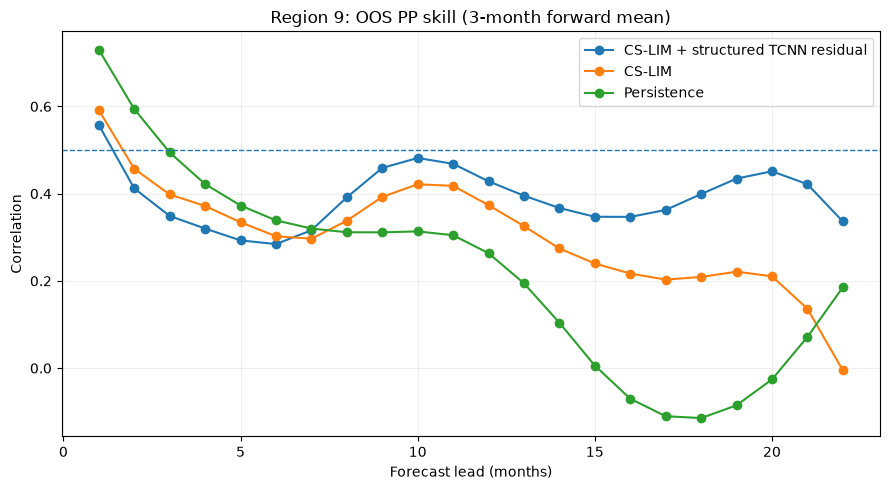

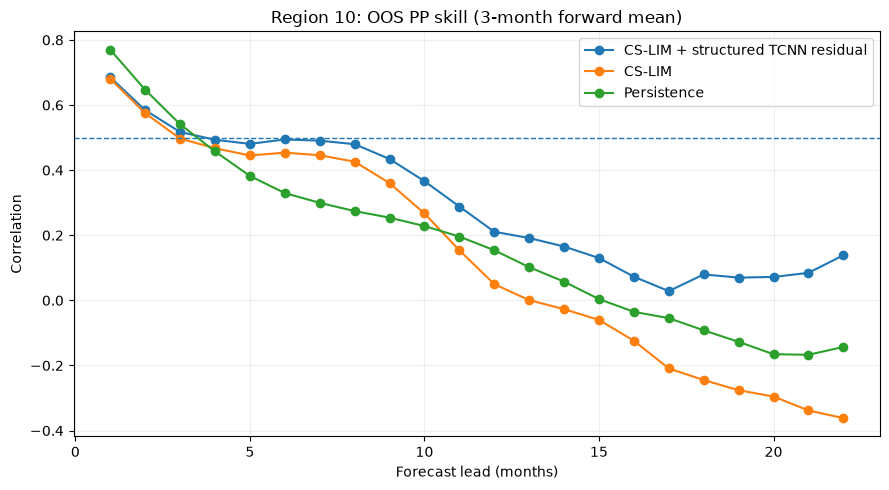

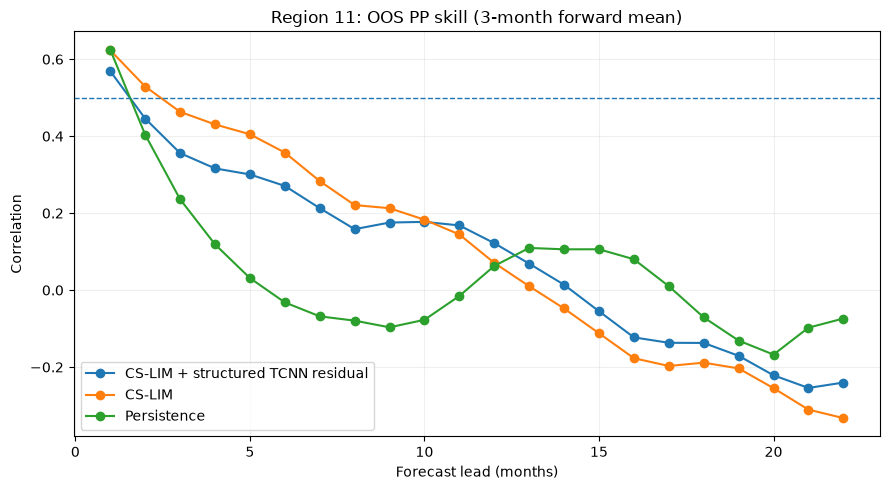

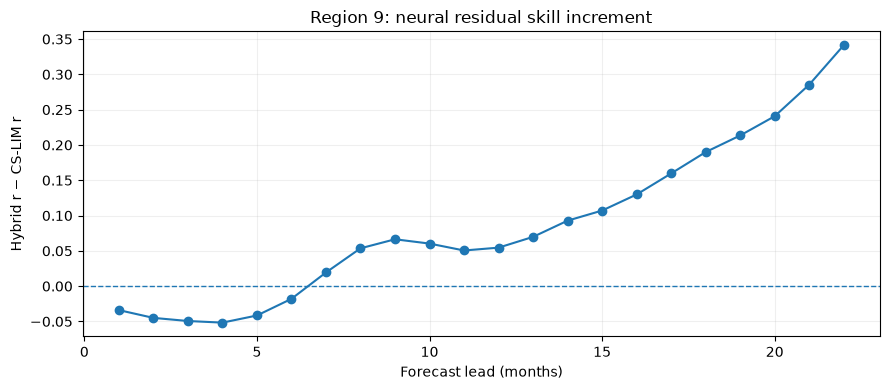

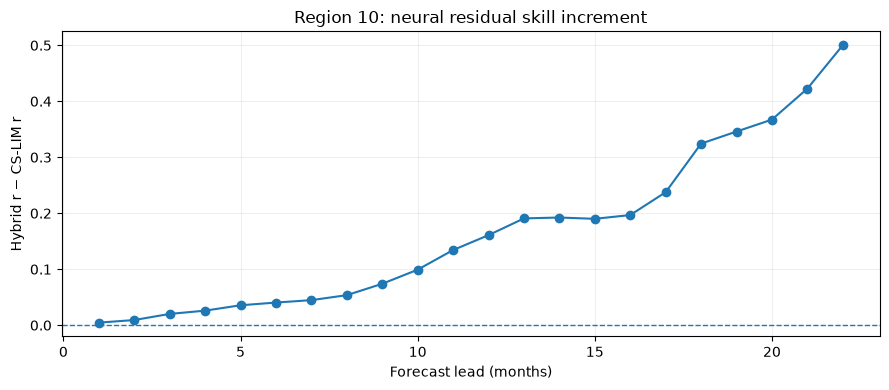

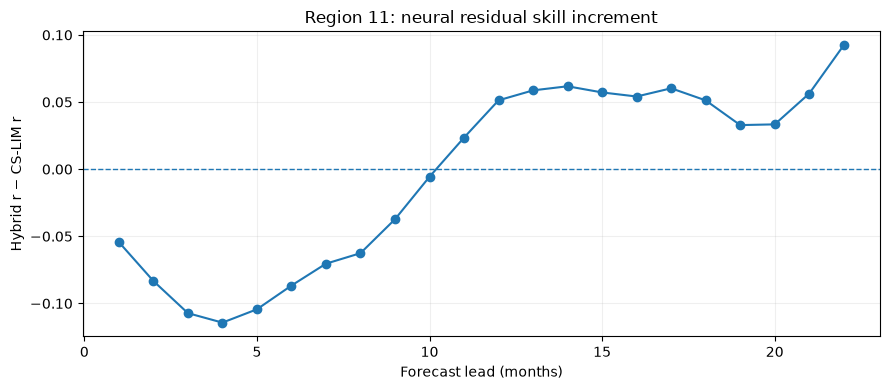

In [17]:
# ============================================================
# Standard comparison
# ============================================================

plot_skill_curves(
    table=skill_table_3month,
    title_suffix=(
        f"{RUNNING_MEAN_WINDOW}-month "
        f"{RUNNING_MEAN_ALIGNMENT} mean"
    ),
)

plot_skill_increment(
    table=skill_table_3month,
)

# Optional:
#
# plot_skill_curves(
#     table=skill_table_monthly,
#     title_suffix="monthly",
# )
#
# plot_amplitude_ratio()
#
# plot_spaghetti_region(
#     region=9,
#     every=3,
#     start_date="2014-01-01",
#     end_date="2021-12-31",
# )
#
# plot_training_history(
#     region=9,
#     fold_id=4,
# )
#
# display(
#     diagnose_pp_contributions(
#         region=9,
#         fold_id=4,
#     )
# )
#
# plot_driver_contributions(
#     region=9,
#     fold_id=4,
# )
